### 랭그래프로 간단한 챗봇 만들기

In [ ]:
# 1. 랭체인 설치
%pip install langchain

# 2. 랭체인에서 OpenAI를 사용하기 위한 패키지
%pip install langchain_openai

# 3. 랭그래프 설치
%pip install langgraph

In [77]:
# import
import os
from langchain_openai import ChatOpenAI  # 랭체인에서 OpenAI 모델을 사용하기 위한 패키지

# api key 설정
from dotenv import load_dotenv  # .env 파일에서 환경변수 불러오기 위한 패키지
load_dotenv()                   # ChatOpenAI(...) 생성 시 내부 OpenAI SDK가 OPENAI_API_KEY 환경변수를 자동 조회해서 요청 헤더에 사용

True

In [78]:
# 모델 초기화
model = ChatOpenAI(model="gpt-4o-mini")
response = model.invoke("안녕 GPT")
print(response.content)

안녕하세요! 어떻게 도와드릴까요?


### 상태 정의하기
랭그래프에서 '상태(State)'는 LLM 이 현재 상태를 관리하도록 돕는 요소
랭그래프의 여러 노드(=에이전트) 가 각자 맡은 일을 수행하도록 구성된다.
그러므로 이 노드들은 상황에 맞게 작업할 수 있도록 필요한 정보를 주고 받아야된다.

상태(state) 클래스에 '필요한 데이터 형식'을 정의한다.
각 노드에서 처리한 결과를 저장하고 다음 노드에 전달한다.

그러므로, 각 작업에 필요한 자료 형태(Dict) 를 상태(state)에 정의해놔야 한다.

# 코드 시퀀스
1. class State(TypeDict) : State 의 dict 형태를 타입으로 정의하고
2. StateGraph(State) : State 타입의 그래프를 생성하고, graph_builder에 저장
3. graph_builder 에 이 노드들을 연결할 것이다.

# 예시 State
{messages : list[str]} # 대화 메시지들의 리스트
-> TypeDict, Annotated 를 사용하여 아래 처럼 표현

class State(TypedDict):
    messages: Annotated[list[str], "대화 메시지들의 리스트"]


# 추가 : TypedDict 와 Annotated 설명
https://wikidocs.net/264613

 - TypedDict : (일반 Dict 보다) 코드 자체가 문서의 역할을 하여 딕셔너리의 구조를 명확히 보여줍니다.
    TypeDict 를 상속받아 "State 는 일반 클래스가 아니라, 이 구조로 딕셔너리 타입을 선언하겠다는 설명"
 - Annotated : 기존 타입에 메타데이터를 추가할 수 있게 해줍니다. 이를 통해 코드의 가독성을 높이고, 더 자세한 타입 정보를 제공할 수 있습니다.
    name: Annotated[str, "사용자 이름"] #Annotated[자료형,메타데이터]

In [85]:
# State 정의하기
# 랭그래프 import
from langgraph.graph import StateGraph, START, END # 상태 그래프를 정의하기 위한 클래스와 상수 (전체 상태, 그래프 시작 노드, 종료 노드)
from langgraph.graph.message import add_messages # 상태 그래프에 메시지를 추가하기 위한 함수

# 타입 정의를 위한 import
from typing import Annotated # 타입 힌트를 위한 함수
from typing import TypedDict # State 클래스를 딕셔너리 형태로 관리하기 위해 사용

# State 클래스 정의 (상태 형태 정의)
class State(TypedDict):
    messages: Annotated[list[str], "대화 메시지들의 리스트"] # messages는 (자료형:) 문자열 리스트 형태로 정의, (메타데이터:) 각 문자열은 대화 메시지를 나타냄

# StateGraph 객체 생성 (graph_builder)
graph_builder = StateGraph(State)

### 노드 생성
랭그래프는 각 노드에서 처리한 결과를 상태에서 관리하고
각 노드를 엣지로 연결하는 그래프 형태로 표현할 것이다.

노드는 그래프 흐름의 한 지점, 한 단계를 의미

# 코드 시퀀스
1. 노드 정의 : 상태에 기반한 응답 생성 노드
2. 노드를 그래프에 추가

# 예시 노드
사용자가 질문하면 답변하는 generate 라는 노드를 가진 랭그래프 만든다.
이 노드는 기존의 대화 내용에 기반해서 답변을 생성하는 역할
 -. input : state 형식의 인자 ; {messages : list[str]} # 대화 메시지들의 리스트
 -. output : dict 형식의 response ; response 결과를 state 에 맞는 형태로 변환한 dict

In [86]:
# 노드 정의 : 상태 기반 응답 생성 노드
def NODE_generate_response(state: State) -> dict:
    messages = state["messages"]
    response = model.invoke(messages)
    print("[DEBUG]"+"*"*20)
    print(response)
    print("[DEBUG]"+"*"*20)

    return {"messages": [response]} # response 객체에서 content 속성만 추출해서 messages 리스트로 반환

# 노드를 그래프에 추가
graph_builder.add_node("generate_response", NODE_generate_response)

### 엣지 설정하기
그래프는 노드 + 엣지로 구성된다.
노드 앞/뒤로 START/END 노드를 지정하고 엣지로 설정한다.

# 코드 시퀀스
1. graph_builder 에 연결관계 선언
2. 흐름 구성 : START - generate_response - END 흐름 구성
3. graph 컴파일

# 컴파일
LangGraph는 먼저:
    - state 정의
    - node 정의
    - edge 연결
이런 식으로 그래프를 설계하고,
그걸 compile()해서 실제 실행 가능한 형태로 바꿔요. Graph API 문서도 그래프를 정의한 뒤 실행 가능한 graph로 다루는 구조를 설명합니다.

In [87]:
# 엣지 설정하기
graph_builder.add_edge(START, "generate_response") # 시작 엣지 -> generate_response 노드
graph_builder.add_edge("generate_response", END)   # generate_response 노드 -> 종료 엣지

# 그래프 컴파일
MY_graph = graph_builder.compile()

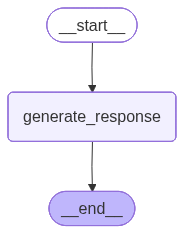

In [88]:
# [+] 그래프 도식화
from IPython.display import display, Image # 주피터 전용

display(Image(MY_graph.get_graph().draw_mermaid_png()))

### 그래프 사용하기

대화 내용을 수동으로 업데이트 하면서 

1. message list 를 State 형식으로 정의
2. 그래프에 State 형식으로 Input (message list)
3. 문장 리스트 기반으로 응답 반환 (END)

### response 의 구조에 대해
첫 문장에 대한 return 인 response 는...
response = MY_graph.invoke({"messages": [MY_1st_message]})
는 model.invoke() 가 만든 LangChain 객체가 담겨있다.(이때, 첫번째 질문은 없다.)
AIMessage(
    content="첫 번째 답변",
    additional_kwargs={},
    response_metadata={...}
)


이때 두번째 문장을 append 한 reponse 의 구조는...
단순 문자열이 두번째 원소로 추가된 형태.
[
    AIMessage(
        content="첫 번째 답변",
        additional_kwargs={},
        response_metadata={...}
    ),
    "두번째 문장"
]

이때 model 내부에서
```python
def _convert_input(self, model_input: LanguageModelInput) -> PromptValue:
    if isinstance(message, str):
        message_ = _create_message_from_message_type("human", message)
```
를 통해 원소가 단순 문자열이면 HumanMessage 로 변환해준다.
[
    AIMessage(content="첫 답변"),
    HumanMessage(content="두 번째 질문")
]
문자열이 자동으로 HumanMassage 로 승격된다.

결과적으로
1. response : 첫 답변
2. response : 첫 답변 + 두번째 질문
3. new response : 두번째 답변

In [89]:
MY_1st_message = "안녕, 나는 랭그래프 공부중"
MY_2nd_message = "내가 공부중인 것에서 중요한 것?"

# 그래프에 첫 질문만 input
response = MY_graph.invoke({"messages": [MY_1st_message]}) #END 만나면서 generate_response의 결과 반환

print(type(response)) # dict
print(response) # 첫 답변 (질문은 없음)
print(response["messages"][0].content) # 모델의 응답 메시지 출력

# 그래프에 첫+둘 문장들 input 
response["messages"].append(MY_2nd_message) # 두번째 메시지 수동 추가
print(response) # 첫 답변 + 두번째 질문 (모델의 응답 메시지 + 두번째 질문)
new_response = MY_graph.invoke(response) # 모델의 응답 메시지
print(new_response) # 두번째 답변 

[DEBUG]********************
content='안녕하세요! 랭그래프에 대해 공부하고 계시군요. 랭그래프는 어떤 부분에 대해 궁금하신가요? 특정한 개념이나 예제에 대해 질문해 주시면 도와드리겠습니다!' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 51, 'prompt_tokens': 17, 'total_tokens': 68, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1cd0c2195a', 'id': 'chatcmpl-DUZj7F0copdtPvpAKiVdjFHX1fuYs', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019d8c8d-02c0-7303-915d-07f00e0ac9a6-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 17, 'output_tokens': 51, 'total_tokens': 68, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
[DEBUG]********************
<class '

In [75]:
# [+] 스트리밍 응답 받기
inputs = {"messages": [("human", "랭그래프에서 중요한 것이 뭔지 알려줘")]}
for chunk, _ in MY_graph.stream(inputs, stream_mode="messages"):
    print(chunk.content, end="")

랭그래프(Rank Graph)는 주로 시스템에서 요소 간의 관계나 중요성을 나타내는 그래픽적 표현입니다. 랭그래프에서 중요하게 고려해야 할 주요 요소는 다음과 같습니다:

1. **노드(Node)**: 그래프의 각 점을 나타내며, 일반적으로 분석하고자 하는 개별 항목이나 개체를 의미합니다.

2. **엣지(Edge)**: 노드 간의 관계를 나타내며, 방향성이 있을 수 있습니다. 방향성이 있는 경우에는 한 노드에서 다른 노드로의 관계를 보여줍니다.

3. **가중치(Weight)**: 특정 엣지에 부여된 값으로, 그 관계의 강도나 중요성을 나타낼 수 있습니다.

4. **계층(Hierarchy)**: 랭그래프는 종종 계층 기반으로 구성되는 경우가 많아, 상위 노드와 하위 노드 간의 관계가 중요합니다.

5. **연결성(Connectivity)**: 노드 간의 연결 정도는 그래프의 전체 구조를 이해하는 데 중요한 요소입니다.

6. **중심성(Centrality)**: 특정 노드가 그래프 내에서 얼마나 중요한지를 나타내는 지표로, 다양한 중심성 측정 방법(예: degree 중심성, betweenness 중심성 등)이 있습니다.

7. **클러스터링(Clustering)**: 비슷한 노드들이 어떻게 그룹화되는지를 나타내며, 이는 정보나 경향을 파악하는 데 도움이 됩니다.

랭그래프를 올바르게 이해하고 분석하는 것은 데이터 시각화, 네트워크 분석, 소셜 미디어 분석 등 다양한 분야에서 중요한 기초가 됩니다.